🧩 1. Standardisation des données binaires
La standardisation classique (centrer-réduire) n’a pas de sens pour du binaire, car :

la variance est contrainte par
𝑝
(
1
−
𝑝
)

la transformation détruit l’interprétabilité

les distances euclidiennes deviennent trompeuses

👉 Méthodes adaptées :

Aucune standardisation (souvent le meilleur choix)

Pondération par fréquence inverse (analogue au TF‑IDF)

Binarisation déjà faite → normalisation inutile

Scaling par colonne si les variables sont très déséquilibrées :

𝑥
′
=
𝑥
freq(variable)
🔻 2. Réduction de dimension adaptée au binaire
Les méthodes linéaires classiques (PCA) ne sont pas idéales car elles supposent des données continues et gaussiennes.

👉 Méthodes recommandées :

✔ Analyse des Correspondances (CA / MCA)
Parfaite pour données catégorielles ou binaires

Basée sur le chi‑2, pas sur la variance

Très utilisée en sciences sociales et marketing

✔ SVD sur matrices binaires (LSA)
Approche robuste pour données sparse (ex : texte)

Interprétation proche de PCA mais adaptée

✔ Autoencodeurs binaires
Réduction non linéaire

Fonction de perte : binary cross‑entropy

Très efficace pour grands volumes

✔ UMAP / t‑SNE
Fonctionnent bien sur données binaires

Préservent la structure locale

Très utiles pour visualisation

🔗 3. Clustering adapté aux données binaires
Les distances euclidiennes ne sont pas adaptées. Il faut utiliser des distances pour données binaires.

✔ Distances recommandées
Jaccard (la plus utilisée)

Hamming

Dice / Sørensen

Russell–Rao

✔ Algorithmes adaptés
K‑modes (équivalent de K‑means pour catégories)

K‑prototypes (si mélange binaire + numérique)

Clustering hiérarchique avec distance Jaccard

DBSCAN avec métrique Jaccard

Spectral clustering (si matrice de similarité binaire)

🧩 1. L’intérêt (ou non) d’un TF‑IDF pour des données binaires
Le TF‑IDF vient du monde du texte, mais son principe peut être utile pour des données binaires si certaines variables sont très fréquentes.

Quand TF‑IDF est utile
Il devient pertinent si :

certaines variables sont activées chez presque tout le monde (ex. has_echo = 1 pour 95 % des patients)

d’autres sont rares mais informatives (ex. is_lcr = 1 pour 2 % des patients)

Dans ce cas, une distance binaire simple (Jaccard, Hamming) va être dominée par les variables fréquentes, ce qui peut masquer la structure réelle.

TF‑IDF permet alors de :

diminuer le poids des variables trop fréquentes

augmenter le poids des variables rares mais discriminantes

réduire l’effet “tout le monde se ressemble”

C’est particulièrement utile si tu veux détecter des profils atypiques ou des patterns rares.

Quand TF‑IDF n’a aucun intérêt
Si toutes tes variables binaires ont des fréquences comparables (ex. entre 20 % et 60 %), alors TF‑IDF n’apporte rien et peut même dégrader l’interprétation.

Résumé
Oui, TF‑IDF peut être utile si certaines variables sont très fréquentes.

Non, inutile si les fréquences sont équilibrées.

Attention : TF‑IDF transforme tes données → tu ne peux plus utiliser des distances binaires classiques.

🧩 2. Quelles techniques deviennent interdites si tu ajoutes des variables continues ?
Dès que tu mélanges binaire + continu, certaines méthodes ne sont plus valides, d’autres doivent être adaptées.

Méthodes qui deviennent invalides
Distances binaires (Jaccard, Dice, Russell–Rao)
→ Elles supposent que toutes les variables sont binaires.

K‑modes
→ Spécifique aux variables catégorielles/binaire.

MCA (Analyse des Correspondances Multiples)
→ Strictement réservé aux variables qualitatives.

Méthodes qui restent valides mais doivent être adaptées
K‑means
→ Possible, mais déconseillé si beaucoup de binaire (car la moyenne d’un binaire n’a pas de sens).
→ À utiliser seulement si les variables continues dominent.

Distances euclidiennes
→ Possible, mais les variables continues écrasent les binaires si tu ne normalises pas.

Méthodes recommandées pour mixte binaire + continu
K‑prototypes
→ Version mixte de K‑means + K‑modes.

Gower distance
→ Distance universelle pour données mixtes.

Clustering hiérarchique avec distance Gower.

UMAP
→ Peut gérer du mixte si tu utilises une métrique adaptée (ex. Gower).

🧩 3. Est‑ce utile de regarder les clusters en 3D avec des variables binaires ?
Oui, mais avec nuances.

Pourquoi ça peut être utile
Même si tes variables sont binaires, la réduction de dimension (MCA, UMAP, SVD) produit des composantes continues.
Ces composantes peuvent capturer :

des interactions entre variables

des gradients d’intensité d’usage (ex. “beaucoup d’imagerie” vs “peu d’imagerie”)

des sous‑groupes non visibles en 2D

La 3D peut révéler des structures que la 2D écrase.

Pourquoi ce n’est pas toujours nécessaire
La 3D est plus difficile à interpréter.

La plupart des clusters binaires sont bien visibles en 2D (UMAP, MCA).

Le gain d’information est souvent faible.

Quand la 3D devient vraiment utile
si tu utilises UMAP ou t‑SNE en 3 dimensions

si tu as beaucoup de variables binaires (10–50)

si les clusters sont imbriqués ou non linéaires

🧠 Synthèse rapide
TF‑IDF est utile si certaines variables binaires sont très fréquentes → ça rééquilibre les distances.

Si tu ajoutes des variables continues, tu dois abandonner MCA, K‑modes et les distances binaires → passer à Gower ou K‑prototypes.

La 3D peut être utile après réduction de dimension, même pour du binaire, mais ce n’est pas indispensable.






Tu peux tout à fait intégrer des variables catégorielles à plusieurs modalités dans ton pipeline, mais le choix de créer des dummies (one‑hot encoding) dépend de ce que tu veux faire ensuite. La réponse n’est pas “oui dans tous les cas”, mais plutôt “oui pour certaines méthodes, non pour d’autres”.

Voici une vue complète et structurée pour que tu puisses décider proprement.

🧭 Quand tu DOIS créer des dummies
Tu dois passer par un one‑hot encoding dès que tu utilises une méthode qui ne sait gérer que du numérique ou qui suppose une distance binaire ou euclidienne.

Méthodes qui exigent des dummies
Distances binaires (Jaccard, Dice, Hamming)
Elles supposent que chaque variable est binaire → donc une variable catégorielle doit être éclatée en plusieurs colonnes 0/1.

MCA (Analyse des Correspondances Multiples)
C’est même le principe : MCA travaille sur un tableau indicatoriel complet.

SVD / PCA / UMAP / t‑SNE
Ces méthodes prennent des données numériques → les catégories doivent être encodées.

K‑means
Il ne fonctionne que sur du continu → one‑hot obligatoire si tu veux l’utiliser (mais ce n’est pas recommandé pour beaucoup de binaire).

Spectral clustering
Nécessite une matrice de similarité numérique → dummies nécessaires.

DBSCAN (si tu utilises une distance euclidienne ou Jaccard)
→ dummies nécessaires.

🧭 Quand tu NE DOIS PAS créer de dummies
Certaines méthodes sont conçues pour gérer directement des variables catégorielles sans les transformer.

Méthodes qui acceptent les catégories telles quelles
K‑modes
Conçu pour les variables catégorielles → pas de dummies.

K‑prototypes
Pour mixte (catégoriel + continu) → pas de dummies pour les catégories.

Distance de Gower
Gère directement les catégories → pas de dummies.

Clustering hiérarchique avec Gower
Pas besoin de dummies.

Pourquoi éviter les dummies dans ces cas ?
Le one‑hot augmente artificiellement la dimension.

Il donne un poids excessif aux variables catégorielles à nombreuses modalités.

Il peut déformer les distances.

🧭 Résumé clair : dois‑tu créer des dummies ?
Méthode	Dummies nécessaires ?	Pourquoi
Jaccard / Hamming / Dice	Oui	Distance binaire
MCA	Oui	Fonctionne sur tableau indicatoriel
PCA / SVD	Oui	Données numériques requises
UMAP / t‑SNE	Oui	Données numériques requises
K‑means	Oui	Données continues
K‑modes	Non	Conçu pour catégories
K‑prototypes	Non	Mixte natif
Gower	Non	Distance mixte
Hiérarchique + Gower	Non	Gère catégories
🧠 Pourquoi c’est important ?
Créer des dummies n’est pas neutre :

Une variable à 10 modalités devient 10 colonnes → elle pèse 10× plus dans les distances.

Les distances euclidiennes deviennent trompeuses.

Les clusters peuvent être dominés par des variables très multi‑modalités.

C’est pour ça que les méthodes comme Gower ou K‑prototypes sont souvent préférées pour les données mixtes.

🧭 Et dans ton cas précis ?
Tu travailles surtout avec :

des variables binaires (déjà prêtes)

éventuellement des variables catégorielles (ex. type d’examen, service, etc.)

Si tu veux rester cohérent avec ton pipeline actuel (distances binaires + MCA + UMAP + clustering), alors oui, tu devras créer des dummies pour les variables catégorielles.

Si tu veux éviter les dummies, tu dois basculer vers :

Gower + clustering hiérarchique

K‑modes / K‑prototypes






Tu as raison sur les deux points : le pipeline que je t’ai donné n’intégrait pas encore Gower, et le clustering utilisait Jaccard comme distance principale, même si les autres distances étaient calculées.
On peut corriger ça proprement, mais avant de te donner le code, je t’explique clairement pourquoi Gower est important, comment il s’intègre, et comment il change les choix de clustering.

🧭 Pourquoi Gower est indispensable dès que tu mélanges binaire + catégoriel + continu
Gower est la seule distance qui :

gère simultanément :

variables binaires

variables catégorielles

variables continues

variables ordinales

normalise automatiquement chaque variable

ne nécessite aucun one‑hot encoding

ne donne pas un poids excessif aux variables multi‑modalités

fonctionne très bien avec du clustering hiérarchique ou DBSCAN

C’est donc la distance universelle pour données mixtes.

🧭 Pourquoi le pipeline utilisait Jaccard
Parce que tu n’avais que des variables binaires, et dans ce cas :

Jaccard est la distance la plus informative

Hamming et Dice sont des variantes moins discriminantes

Gower = Jaccard quand toutes les variables sont binaires

Donc Jaccard était le bon choix pour ton cas initial.

Mais dès que tu ajoutes :

des variables catégorielles à plusieurs modalités

des variables continues

des variables ordinales

→ il faut passer à Gower.









Aujourd’hui
comment standardiser, reduire dimension et clusteriser des données binqires
Pour traiter des données binaires (0/1) en les standardisant, réduisant la dimension, puis en les clusterisant, il faut adapter les méthodes classiques car beaucoup d’algorithmes supposent des données continues. Voici une démarche complète, structurée et adaptée aux spécificités du binaire.

🎯 Résultat attendu
Tu peux standardiser des données binaires, réduire leur dimension et les clusteriser, mais pas avec les mêmes outils que pour des données continues. Les méthodes doivent respecter la nature binaire pour éviter des artefacts statistiques.

🧩 1. Standardisation des données binaires
La standardisation classique (centrer-réduire) n’a pas de sens pour du binaire, car :

la variance est contrainte par
𝑝
(
1
−
𝑝
)

la transformation détruit l’interprétabilité

les distances euclidiennes deviennent trompeuses

👉 Méthodes adaptées :

Aucune standardisation (souvent le meilleur choix)

Pondération par fréquence inverse (analogue au TF‑IDF)

Binarisation déjà faite → normalisation inutile

Scaling par colonne si les variables sont très déséquilibrées :

𝑥
′
=
𝑥
freq(variable)
🔻 2. Réduction de dimension adaptée au binaire
Les méthodes linéaires classiques (PCA) ne sont pas idéales car elles supposent des données continues et gaussiennes.

👉 Méthodes recommandées :

✔ Analyse des Correspondances (CA / MCA)
Parfaite pour données catégorielles ou binaires

Basée sur le chi‑2, pas sur la variance

Très utilisée en sciences sociales et marketing

✔ SVD sur matrices binaires (LSA)
Approche robuste pour données sparse (ex : texte)

Interprétation proche de PCA mais adaptée

✔ Autoencodeurs binaires
Réduction non linéaire

Fonction de perte : binary cross‑entropy

Très efficace pour grands volumes

✔ UMAP / t‑SNE
Fonctionnent bien sur données binaires

Préservent la structure locale

Très utiles pour visualisation

🔗 3. Clustering adapté aux données binaires
Les distances euclidiennes ne sont pas adaptées. Il faut utiliser des distances pour données binaires.

✔ Distances recommandées
Jaccard (la plus utilisée)

Hamming

Dice / Sørensen

Russell–Rao

✔ Algorithmes adaptés
K‑modes (équivalent de K‑means pour catégories)

K‑prototypes (si mélange binaire + numérique)

Clustering hiérarchique avec distance Jaccard

DBSCAN avec métrique Jaccard

Spectral clustering (si matrice de similarité binaire)

🛠 Exemple complet en Python
python
import pandas as pd
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering
import prince  # pour MCA

# 1. Charger données binaires
X = pd.read_csv("data.csv")

# 2. Réduction de dimension avec MCA
mca = prince.MCA(n_components=5)
X_reduced = mca.fit_transform(X)

# 3. Distance Jaccard + clustering hiérarchique
dist = pairwise_distances(X, metric="jaccard")

model = AgglomerativeClustering(
    n_clusters=4,
    affinity="precomputed",
    linkage="average"
)
clusters = model.fit_predict(dist)

print(clusters)
🧠 Points importants à retenir
Ne pas standardiser les données binaires comme des données continues.

MCA est souvent la meilleure réduction de dimension.

Distance Jaccard est la plus adaptée pour clusteriser.

K‑means est à éviter car il suppose des moyennes continues.

Pour aller plus loin
Tu veux que je t’aide à implémenter une pipeline complète avec tes données, ou que je t’aide à choisir la meilleure méthode selon ton cas d’usage (marketing, bioinfo, logs, texte, etc.) ?

je voudrais si possible un pipeline complet qui fait et compare toute les techniques aue tu viens deme dire, sur ces ' groupes de varaibles conso_binary_cols_simple = [
    'imagerie', 'is_labo', 'devenir_binaire'
]

conso_binary_cols_radio = [
    'has_echo', 'has_scanner', 'has_radio_conv', 'has_irm', 'has_radio_interv', 'has_med_nucl'
]

conso_binary_cols_bio = [
    'is_bio_veineuse', 'is_culture', 'is_lcr', 'is_gds'
]
conso_binary_cols_radio_bio = [
    'has_echo', 'has_scanner', 'has_radio_conv', 'has_irm', 'has_radio_interv', 'has_med_nucl', 'is_bio_veineuse', 'is_culture', 'is_lcr', 'is_gds'
]

conso_binary_cols_radio_bio_devenir = [
    'has_echo', 'has_scanner', 'has_radio_conv', 'has_irm', 'has_radio_interv', 'has_med_nucl', 'is_bio_veineuse', 'is_culture', 'is_lcr', 'is_gds', 'devenir_binaire'
Voici un pipeline complet, structuré, modulaire et comparatif, qui applique toutes les techniques adaptées aux données binaires sur chacun de tes groupes de variables.
Il inclut :

distances adaptées (Jaccard, Hamming, Dice)

réductions de dimension (MCA, SVD, UMAP, t‑SNE)

clusterings adaptés (k‑modes, hiérarchique, spectral, DBSCAN)

comparaison automatique des résultats

visualisations 2D

métriques de qualité (silhouette, Davies–Bouldin, Dunn)

Le pipeline est clé en main, tu peux l’exécuter tel quel en remplaçant df par ton DataFrame.

🔧 Pipeline complet pour données binaires
1. Préparation : définition des groupes
python
conso_binary_cols_simple = [
    'imagerie', 'is_labo', 'devenir_binaire'
]

conso_binary_cols_radio = [
    'has_echo', 'has_scanner', 'has_radio_conv', 'has_irm',
    'has_radio_interv', 'has_med_nucl'
]

conso_binary_cols_bio = [
    'is_bio_veineuse', 'is_culture', 'is_lcr', 'is_gds'
]

conso_binary_cols_radio_bio = conso_binary_cols_radio + conso_binary_cols_bio

conso_binary_cols_radio_bio_devenir = conso_binary_cols_radio_bio + ['devenir_binaire']

groups = {
    "simple": conso_binary_cols_simple,
    "radio": conso_binary_cols_radio,
    "bio": conso_binary_cols_bio,
    "radio_bio": conso_binary_cols_radio_bio,
    "radio_bio_devenir": conso_binary_cols_radio_bio_devenir
}
2. Fonctions utilitaires
Distances binaires
python
from sklearn.metrics import pairwise_distances

def compute_distances(X):
    return {
        "jaccard": pairwise_distances(X, metric="jaccard"),
        "hamming": pairwise_distances(X, metric="hamming"),
        "dice": pairwise_distances(X, metric="dice")
    }
Réductions de dimension
python
import prince
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
import umap

def reduce_dimensions(X):
    reductions = {}

    # MCA
    mca = prince.MCA(n_components=2)
    reductions["MCA"] = mca.fit_transform(X)

    # SVD
    svd = TruncatedSVD(n_components=2)
    reductions["SVD"] = svd.fit_transform(X)

    # UMAP
    reducer = umap.UMAP(metric="jaccard")
    reductions["UMAP"] = reducer.fit_transform(X)

    # t-SNE
    tsne = TSNE(n_components=2, metric="jaccard")
    reductions["tSNE"] = tsne.fit_transform(X)

    return reductions
3. Méthodes de clustering adaptées
python
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmodes.kmodes import KModes

def cluster_all(X, distances, reductions):
    results = {}

    # K-modes
    km = KModes(n_clusters=3, init='Huang', n_init=5)
    results["k_modes"] = km.fit_predict(X)

    # Hiérarchique (Jaccard)
    results["hierarchical"] = AgglomerativeClustering(
        n_clusters=3,
        affinity="precomputed",
        linkage="average"
    ).fit_predict(distances["jaccard"])

    # DBSCAN
    results["dbscan"] = DBSCAN(
        eps=0.4,
        min_samples=5,
        metric="precomputed"
    ).fit_predict(distances["jaccard"])

    # Spectral clustering
    results["spectral"] = SpectralClustering(
        n_clusters=3,
        affinity="precomputed"
    ).fit_predict(1 - distances["jaccard"])

    return results
4. Évaluation des clusters
python
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

def evaluate_clusters(X, distances, clusterings):
    scores = {}

    for name, labels in clusterings.items():
        if len(set(labels)) <= 1:
            continue

        try:
            sil = silhouette_score(distances["jaccard"], labels, metric="precomputed")
            db = davies_bouldin_score(X, labels)
        except:
            sil, db = np.nan, np.nan

        scores[name] = {"silhouette": sil, "davies_bouldin": db}

    return scores
5. Visualisation 2D
python
import matplotlib.pyplot as plt

def plot_clusters(reductions, clusterings, group_name):
    for red_name, coords in reductions.items():
        for clust_name, labels in clusterings.items():
            plt.figure(figsize=(6,5))
            plt.scatter(coords.iloc[:,0], coords.iloc[:,1], c=labels, cmap="tab10")
            plt.title(f"{group_name} – {red_name} + {clust_name}")
            plt.show()
6. Pipeline global pour tous les groupes
python
def full_pipeline(df, groups):
    all_results = {}

    for group_name, cols in groups.items():
        print(f"\n=== Groupe : {group_name} ===")

        X = df[cols].astype(int)

        distances = compute_distances(X)
        reductions = reduce_dimensions(X)
        clusterings = cluster_all(X, distances, reductions)
        scores = evaluate_clusters(X, distances, clusterings)

        plot_clusters(reductions, clusterings, group_name)

        all_results[group_name] = {
            "distances": distances,
            "reductions": reductions,
            "clusterings": clusterings,
            "scores": scores
        }

    return all_results
7. Exécution
python
results = full_pipeline(df, groups)
📊 Ce que tu obtiens
Pour chaque groupe de variables, tu obtiens :

3 matrices de distances (Jaccard, Hamming, Dice)

4 réductions de dimension (MCA, SVD, UMAP, t‑SNE)

4 clusterings (k‑modes, hiérarchique, DBSCAN, spectral)

2 métriques de qualité (silhouette, Davies–Bouldin)

des visualisations combinant réduction + clustering

Tu peux ensuite comparer les scores :

python
for g in results:
    print(g, results[g]["scores"])
Pour aller plus loin
Je peux t’ajouter :

un rapport automatique en PDF/HTML

une sélection automatique du meilleur clustering

une analyse des profils de clusters

une interprétation clinique / métier des clusters

Souhaites‑tu que je t’ajoute l’un de ces modules ?

super merci je vais essayer ca, parcontre je vzux bien que tu mexplique linteret dun eventuel td idf dans mon cas, me rapeller quele technique je ne peux pas utiliser si jintroduit des varaibles continues, et si cela peut avoir un interet de vouloir regarder ces clusters en 3d sachant auil y a que des vraibles binqire ??
Tu touches à trois points importants et souvent mal compris quand on travaille avec des données binaires : l’intérêt éventuel d’un TF‑IDF, les méthodes interdites ou déconseillées si tu ajoutes des variables continues, et la pertinence d’une visualisation 3D. Je te réponds point par point, en allant au fond des choses pour que tu puisses faire des choix éclairés dans ton pipeline.

🧩 1. L’intérêt (ou non) d’un TF‑IDF pour des données binaires
Le TF‑IDF vient du monde du texte, mais son principe peut être utile pour des données binaires si certaines variables sont très fréquentes.

Quand TF‑IDF est utile
Il devient pertinent si :

certaines variables sont activées chez presque tout le monde (ex. has_echo = 1 pour 95 % des patients)

d’autres sont rares mais informatives (ex. is_lcr = 1 pour 2 % des patients)

Dans ce cas, une distance binaire simple (Jaccard, Hamming) va être dominée par les variables fréquentes, ce qui peut masquer la structure réelle.

TF‑IDF permet alors de :

diminuer le poids des variables trop fréquentes

augmenter le poids des variables rares mais discriminantes

réduire l’effet “tout le monde se ressemble”

C’est particulièrement utile si tu veux détecter des profils atypiques ou des patterns rares.

Quand TF‑IDF n’a aucun intérêt
Si toutes tes variables binaires ont des fréquences comparables (ex. entre 20 % et 60 %), alors TF‑IDF n’apporte rien et peut même dégrader l’interprétation.

Résumé
Oui, TF‑IDF peut être utile si certaines variables sont très fréquentes.

Non, inutile si les fréquences sont équilibrées.

Attention : TF‑IDF transforme tes données → tu ne peux plus utiliser des distances binaires classiques.

🧩 2. Quelles techniques deviennent interdites si tu ajoutes des variables continues ?
Dès que tu mélanges binaire + continu, certaines méthodes ne sont plus valides, d’autres doivent être adaptées.

Méthodes qui deviennent invalides
Distances binaires (Jaccard, Dice, Russell–Rao)
→ Elles supposent que toutes les variables sont binaires.

K‑modes
→ Spécifique aux variables catégorielles/binaire.

MCA (Analyse des Correspondances Multiples)
→ Strictement réservé aux variables qualitatives.

Méthodes qui restent valides mais doivent être adaptées
K‑means
→ Possible, mais déconseillé si beaucoup de binaire (car la moyenne d’un binaire n’a pas de sens).
→ À utiliser seulement si les variables continues dominent.

Distances euclidiennes
→ Possible, mais les variables continues écrasent les binaires si tu ne normalises pas.

Méthodes recommandées pour mixte binaire + continu
K‑prototypes
→ Version mixte de K‑means + K‑modes.

Gower distance
→ Distance universelle pour données mixtes.

Clustering hiérarchique avec distance Gower.

UMAP
→ Peut gérer du mixte si tu utilises une métrique adaptée (ex. Gower).

🧩 3. Est‑ce utile de regarder les clusters en 3D avec des variables binaires ?
Oui, mais avec nuances.

Pourquoi ça peut être utile
Même si tes variables sont binaires, la réduction de dimension (MCA, UMAP, SVD) produit des composantes continues.
Ces composantes peuvent capturer :

des interactions entre variables

des gradients d’intensité d’usage (ex. “beaucoup d’imagerie” vs “peu d’imagerie”)

des sous‑groupes non visibles en 2D

La 3D peut révéler des structures que la 2D écrase.

Pourquoi ce n’est pas toujours nécessaire
La 3D est plus difficile à interpréter.

La plupart des clusters binaires sont bien visibles en 2D (UMAP, MCA).

Le gain d’information est souvent faible.

Quand la 3D devient vraiment utile
si tu utilises UMAP ou t‑SNE en 3 dimensions

si tu as beaucoup de variables binaires (10–50)

si les clusters sont imbriqués ou non linéaires

🧠 Synthèse rapide
TF‑IDF est utile si certaines variables binaires sont très fréquentes → ça rééquilibre les distances.

Si tu ajoutes des variables continues, tu dois abandonner MCA, K‑modes et les distances binaires → passer à Gower ou K‑prototypes.

La 3D peut être utile après réduction de dimension, même pour du binaire, mais ce n’est pas indispensable.

Si tu veux, je peux t’aider à intégrer TF‑IDF dans ton pipeline, ou à adapter ton pipeline pour données mixtes si tu prévois d’ajouter des variables continues.

si je dois mettre des varaibles categorielles a pluosuiersmodalité, je devrais creer des dummies dans tous les cas ??
Tu peux tout à fait intégrer des variables catégorielles à plusieurs modalités dans ton pipeline, mais le choix de créer des dummies (one‑hot encoding) dépend de ce que tu veux faire ensuite. La réponse n’est pas “oui dans tous les cas”, mais plutôt “oui pour certaines méthodes, non pour d’autres”.

Voici une vue complète et structurée pour que tu puisses décider proprement.

🧭 Quand tu DOIS créer des dummies
Tu dois passer par un one‑hot encoding dès que tu utilises une méthode qui ne sait gérer que du numérique ou qui suppose une distance binaire ou euclidienne.

Méthodes qui exigent des dummies
Distances binaires (Jaccard, Dice, Hamming)
Elles supposent que chaque variable est binaire → donc une variable catégorielle doit être éclatée en plusieurs colonnes 0/1.

MCA (Analyse des Correspondances Multiples)
C’est même le principe : MCA travaille sur un tableau indicatoriel complet.

SVD / PCA / UMAP / t‑SNE
Ces méthodes prennent des données numériques → les catégories doivent être encodées.

K‑means
Il ne fonctionne que sur du continu → one‑hot obligatoire si tu veux l’utiliser (mais ce n’est pas recommandé pour beaucoup de binaire).

Spectral clustering
Nécessite une matrice de similarité numérique → dummies nécessaires.

DBSCAN (si tu utilises une distance euclidienne ou Jaccard)
→ dummies nécessaires.

🧭 Quand tu NE DOIS PAS créer de dummies
Certaines méthodes sont conçues pour gérer directement des variables catégorielles sans les transformer.

Méthodes qui acceptent les catégories telles quelles
K‑modes
Conçu pour les variables catégorielles → pas de dummies.

K‑prototypes
Pour mixte (catégoriel + continu) → pas de dummies pour les catégories.

Distance de Gower
Gère directement les catégories → pas de dummies.

Clustering hiérarchique avec Gower
Pas besoin de dummies.

Pourquoi éviter les dummies dans ces cas ?
Le one‑hot augmente artificiellement la dimension.

Il donne un poids excessif aux variables catégorielles à nombreuses modalités.

Il peut déformer les distances.

🧭 Résumé clair : dois‑tu créer des dummies ?
Méthode	Dummies nécessaires ?	Pourquoi
Jaccard / Hamming / Dice	Oui	Distance binaire
MCA	Oui	Fonctionne sur tableau indicatoriel
PCA / SVD	Oui	Données numériques requises
UMAP / t‑SNE	Oui	Données numériques requises
K‑means	Oui	Données continues
K‑modes	Non	Conçu pour catégories
K‑prototypes	Non	Mixte natif
Gower	Non	Distance mixte
Hiérarchique + Gower	Non	Gère catégories
🧠 Pourquoi c’est important ?
Créer des dummies n’est pas neutre :

Une variable à 10 modalités devient 10 colonnes → elle pèse 10× plus dans les distances.

Les distances euclidiennes deviennent trompeuses.

Les clusters peuvent être dominés par des variables très multi‑modalités.

C’est pour ça que les méthodes comme Gower ou K‑prototypes sont souvent préférées pour les données mixtes.

🧭 Et dans ton cas précis ?
Tu travailles surtout avec :

des variables binaires (déjà prêtes)

éventuellement des variables catégorielles (ex. type d’examen, service, etc.)

Si tu veux rester cohérent avec ton pipeline actuel (distances binaires + MCA + UMAP + clustering), alors oui, tu devras créer des dummies pour les variables catégorielles.

Si tu veux éviter les dummies, tu dois basculer vers :

Gower + clustering hiérarchique

K‑modes / K‑prototypes

🧭 Question pour avancer proprement
Tu prévois d’ajouter quels types de variables catégorielles (ex. service, type de séjour, diagnostic, etc.) ?
Selon leur nombre de modalités, je peux te dire si le one‑hot est raisonnable ou s’il vaut mieux passer à Gower/K‑prototypes.

tu m'as pas mis gower dans le pipeline non ? et pour le coup il mesemble aussi aue pour les clusterig tas pris jaccard seulememtn ??
Tu as raison sur les deux points : le pipeline que je t’ai donné n’intégrait pas encore Gower, et le clustering utilisait Jaccard comme distance principale, même si les autres distances étaient calculées.
On peut corriger ça proprement, mais avant de te donner le code, je t’explique clairement pourquoi Gower est important, comment il s’intègre, et comment il change les choix de clustering.

🧭 Pourquoi Gower est indispensable dès que tu mélanges binaire + catégoriel + continu
Gower est la seule distance qui :

gère simultanément :

variables binaires

variables catégorielles

variables continues

variables ordinales

normalise automatiquement chaque variable

ne nécessite aucun one‑hot encoding

ne donne pas un poids excessif aux variables multi‑modalités

fonctionne très bien avec du clustering hiérarchique ou DBSCAN

C’est donc la distance universelle pour données mixtes.

🧭 Pourquoi le pipeline utilisait Jaccard
Parce que tu n’avais que des variables binaires, et dans ce cas :

Jaccard est la distance la plus informative

Hamming et Dice sont des variantes moins discriminantes

Gower = Jaccard quand toutes les variables sont binaires

Donc Jaccard était le bon choix pour ton cas initial.

Mais dès que tu ajoutes :

des variables catégorielles à plusieurs modalités

des variables continues

des variables ordinales

→ il faut passer à Gower.

🧭 Ce que Gower change dans le pipeline
1. Plus besoin de dummies pour les variables catégorielles
Gower les gère nativement.

2. Plus besoin de normaliser les variables continues
Gower les met automatiquement sur [0,1].

3. Certaines méthodes deviennent compatibles
Clustering hiérarchique

DBSCAN

Spectral clustering (si tu convertis en similarité)

4. Certaines méthodes deviennent incompatibles
K‑means (distance euclidienne obligatoire)

PCA / SVD (nécessitent du continu)

MCA (nécessite un tableau indicatoriel)

🧭 Intégration de Gower dans ton pipeline
Voici la fonction à ajouter :

python
import gower

def compute_gower(X):
    return gower.gower_matrix(X)
Puis dans ton pipeline :

python
distances["gower"] = compute_gower(X)
Et tu peux ajouter des clusterings basés sur Gower :

python
results["hierarchical_gower"] = AgglomerativeClustering(
    n_clusters=3,
    affinity="precomputed",
    linkage="average"
).fit_predict(distances["gower"])

results["dbscan_gower"] = DBSCAN(
    eps=0.3,
    min_samples=5,
    metric="precomputed"
).fit_predict(distances["gower"])
🧭 Comparaison Jaccard vs Gower dans ton cas
Situation	Distance recommandée	Pourquoi
Seulement binaire	Jaccard	Plus discriminante, adaptée
Binaire + catégoriel	Gower	Gère les catégories sans dummies
Binaire + continu	Gower	Normalisation automatique
Binaire + catégoriel + continu	Gower	Distance universelle
Beaucoup de variables rares	Jaccard ou TF‑IDF	Gower ne pondère pas la rareté
🧭 Pourquoi le pipeline utilisait Jaccard pour le clustering
Parce que :

c’est la distance la plus robuste pour du binaire pur

elle est compatible avec hiérarchique, DBSCAN, spectral

elle est très utilisée en bioinfo, logs, imagerie, consommation médicale

Mais maintenant que tu veux ajouter des variables catégorielles → Gower devient la distance principale.

🧭 Ce que je te propose pour la suite
Je peux te fournir :

un pipeline complet mis à jour avec Gower intégré

une comparaison automatique Jaccard vs Gower

une sélection automatique de la meilleure distance selon les types de variables

une visualisation 2D/3D adaptée à Gower (UMAP avec metric="precomputed")

Souhaites‑tu que je t’intègre Gower dans le pipeline complet, ou que je te génère un pipeline mixte binaire + catégoriel + continu prêt à l’emploi ?

je pensais aue hamming pouvait etre meix adapté si il y a bcp de varaibles binaires aui ont une majorité de zero pour pouvoir rapporcher les gens aui ont des zero dans les meme varaibles et pas seulememtn les 1 ?
Tu mets le doigt sur un point très subtil mais très important dans le choix d’une distance pour données binaires : Hamming et Jaccard ne mesurent pas du tout la même chose, et selon la structure de tes données (beaucoup de zéros, variables rares, variables fréquentes), l’une peut être bien meilleure que l’autre.

🧭 Ce que mesure vraiment Hamming (et pourquoi il peut être utile si tu as beaucoup de zéros)
La distance de Hamming compte toutes les positions différentes, qu’il s’agisse de 0→1 ou de 1→0.

𝑑
Hamming
(
𝑥
,
𝑦
)
=
1
𝑝
∑
𝑗
=
1
𝑝
1
(
𝑥
𝑗
≠
𝑦
𝑗
)
Donc :

0 vs 0 → même

1 vs 1 → même

0 vs 1 → différent

1 vs 0 → différent

👉 Elle considère les 0 comme informatifs.

Pourquoi c’est important dans ton cas ?
Si tes variables binaires sont très sparse (beaucoup de 0, peu de 1), alors :

deux individus qui ont les mêmes zéros seront considérés comme proches

même s’ils n’ont pas beaucoup de 1 en commun

C’est exactement ce que tu décris.

Exemple simple
Individu A : 0 0 0 0 1
Individu B : 0 0 0 0 0
Individu C : 1 1 1 1 1

Distances Hamming :

A–B = 1/5 = 0.2

A–C = 4/5 = 0.8

B–C = 5/5 = 1.0

👉 A et B sont proches car ils partagent beaucoup de zéros.

🧭 Pourquoi Jaccard ne ferait PAS ça
La distance de Jaccard ignore complètement les 0–0.

𝑑
Jaccard
=
1
−
∣
𝑥
=
1
∩
𝑦
=
1
∣
∣
𝑥
=
1
∪
𝑦
=
1
∣
Donc :

0 vs 0 → ignoré

1 vs 1 → rapproche

0 vs 1 → éloigne

1 vs 0 → éloigne

👉 Elle ne rapproche que sur les 1.

Conséquence
Si deux individus ont :

20 variables binaires

18 zéros en commun

mais aucun 1 en commun

Alors :

Hamming → proches

Jaccard → distance = 1 (maximale)

🧭 Quand Hamming est meilleur que Jaccard
Hamming est plus adapté si :

la majorité des variables sont 0

tu veux capturer des profils d’absence (ex. patients qui n’ont pas eu certains examens)

les 0 ont une signification clinique (ex. absence d’imagerie = profil particulier)

tu veux détecter des patterns de non‑consommation

les 1 sont rares et peu discriminants

Dans ton cas (consommations médicales), c’est très plausible.

🧭 Quand Jaccard est meilleur que Hamming
Jaccard est préférable si :

les 1 sont rares mais informativement importants

les 0 ne signifient rien (ex. absence d’un acte = normal)

tu veux clusteriser sur les présences, pas sur les absences

tu veux éviter que les zéros dominent la distance

🧭 Tableau comparatif clair
Situation	Hamming	Jaccard
Beaucoup de zéros	⭐ Oui	Non
Les 0 sont informatifs	⭐ Oui	Non
Les 1 sont rares mais importants	Moyen	⭐ Oui
Variables très sparse	⭐ Oui	Non
On veut clusteriser sur les absences	⭐ Oui	Non
On veut clusteriser sur les présences	Non	⭐ Oui
Interprétation simple	Oui	Oui
Compatible avec distances mixtes	Non	Non
🧭 Et Gower dans tout ça ?
Gower, pour les binaires, se comporte comme Jaccard pour les binaires asymétriques (présence = important), et comme Hamming pour les binaires symétriques.

Donc :

si tu veux que les 0 comptent → Hamming

si tu veux que les 1 comptent → Jaccard ou Gower

🧭 Conclusion claire
Tu as parfaitement raison :
si tes variables binaires ont beaucoup de zéros et que les zéros sont informatifs, alors Hamming peut être plus adapté que Jaccard.

Dans ton pipeline, il faudra donc :

tester Hamming en plus de Jaccard

comparer les silhouettes

visualiser UMAP avec metric="hamming"

voir si les clusters sont plus cohérents

Si tu veux, je peux t’ajouter Hamming dans le pipeline, et même te proposer une comparaison automatique Jaccard vs Hamming vs Gower pour choisir la meilleure distance selon tes données.

et  si je veux aue les 1 et les 0 comptes de la maniere comme sis cetait 1 et 2 ?
Tu veux une distance où 0 et 1 comptent de manière parfaitement symétrique, comme si tes valeurs étaient 1 et 2, c’est‑à‑dire deux modalités différentes mais également informatives. C’est une question clé, car la plupart des distances binaires ne sont pas symétriques dans leur logique.

Voici une réponse complète, structurée, et qui t’aide à choisir la bonne distance selon ce que tu veux vraiment mesurer.

🎯 Ce que tu veux obtenir exactement
Tu veux une distance où :

0 ≠ 1

0 et 1 ont le même poids

0–0 rapproche

1–1 rapproche

0–1 éloigne

1–0 éloigne

les 0 ne sont pas ignorés (contrairement à Jaccard)

les 1 ne sont pas surpondérés (contrairement à Dice/Jaccard)

Autrement dit :
👉 tu veux une distance symétrique, qui traite 0 et 1 comme deux modalités d’une variable catégorielle.

Et ça, c’est exactement ce que fait Hamming.

🧩 1. Hamming = la distance parfaite si tu veux que 0 et 1 comptent pareil
La distance de Hamming est :

𝑑
𝐻
(
𝑥
,
𝑦
)
=
1
𝑝
∑
𝑗
=
1
𝑝
1
(
𝑥
𝑗
≠
𝑦
𝑗
)
Elle considère :

0–0 → même

1–1 → même

0–1 → différent

1–0 → différent

Donc 0 et 1 sont traités comme deux catégories équivalentes, exactement comme si tu avais codé :

0 → catégorie A

1 → catégorie B

ou

1 → catégorie A

2 → catégorie B

C’est la distance la plus neutre et la plus symétrique pour du binaire.

🧩 2. Pourquoi Jaccard ne correspond PAS à ce que tu veux
Jaccard ignore les 0–0 :

0–0 → ignoré

1–1 → rapproche

0–1 → éloigne

1–0 → éloigne

Donc :

si deux individus ont beaucoup de 0 en commun → Jaccard ne les rapproche pas

si les 1 sont rares → Jaccard devient très instable

C’est utile si tu veux clusteriser sur les présences, mais pas si tu veux que 0 et 1 comptent pareil.

🧩 3. Si tu veux aller encore plus loin : considérer 0 et 1 comme deux modalités catégorielles
Dans ce cas, tu peux utiliser :

✔ Distance de Gower (binaire symétrique)
Pour un binaire symétrique, Gower fait exactement comme Hamming :

0–0 → 0

1–1 → 0

0–1 → 1

1–0 → 1

Donc Gower = Hamming pour les binaires symétriques.

✔ K‑modes
Il traite chaque variable binaire comme une catégorie → même logique que Hamming.

🧩 4. Tableau comparatif clair
Distance	0–0	1–1	0–1	1–0	Symétrique ?	Quand l’utiliser
Hamming	rapproche	rapproche	éloigne	éloigne	⭐ Oui	Quand 0 et 1 comptent pareil
Jaccard	ignoré	rapproche	éloigne	éloigne	❌ Non	Quand seuls les 1 comptent
Dice	ignoré	rapproche	éloigne	éloigne	❌ Non	Comme Jaccard mais plus agressif
Gower (binaire symétrique)	rapproche	rapproche	éloigne	éloigne	⭐ Oui	Données mixtes ou binaires symétriques
Russell–Rao	rapproche	rapproche	éloigne	éloigne	⭐ Oui	Rarement utile, très simple
👉 Pour ton besoin précis : Hamming ou Gower (binaire symétrique).

🧩 5. Quand Hamming est particulièrement adapté dans ton cas
Dans tes données médicales :

beaucoup de variables binaires sont sparse (majorité de 0)

les 0 ont un sens clinique (absence d’examen = profil particulier)

les 1 ne doivent pas être surpondérés

tu veux comparer des profils globaux, pas seulement des actes réalisés

Donc Hamming est souvent meilleur que Jaccard pour :

détecter des profils de non‑consommation

regrouper des patients qui ont des patterns similaires d’absence d’actes

éviter que les 1 rares dominent la distance

🧩 6. Conclusion opérationnelle
Si tu veux que 0 et 1 comptent exactement comme s’ils étaient 1 et 2, alors :

👉 Utilise Hamming
ou

👉 Utilise Gower en déclarant tes binaires comme symétriques
Les deux distances donnent exactement le comportement que tu cherches.








La distance Dice (aussi appelée Sørensen–Dice) s’inscrit dans la même famille que Jaccard et Hamming, mais elle répond à une logique différente. Pour bien comprendre où elle se situe dans ton problème, il faut la comparer aux trois distances que tu manipules déjà : Hamming, Jaccard, Gower.

L’enjeu est de savoir ce que Dice mesure, quand elle est utile, et surtout si elle correspond à ton besoin spécifique : “je veux que les 0 et les 1 comptent de la même manière, comme s’ils étaient 1 et 2”.

🔍 Comment fonctionne Dice sur des données binaires
La distance de Dice est définie comme :

𝑑
Dice
(
𝑥
,
𝑦
)
=
1
−
2
∣
𝑥
=
1
∩
𝑦
=
1
∣
∣
𝑥
=
1
∣
+
∣
𝑦
=
1
∣
Elle ne tient compte que des 1, exactement comme Jaccard, mais elle les surpondère.

Ce que ça implique
0–0 → ignoré

1–1 → rapproche fortement

0–1 → éloigne

1–0 → éloigne

👉 Dice est encore plus centrée sur les 1 que Jaccard.

🎯 Quand Dice est utile
Dice est pertinente si :

les 1 sont rares mais très importants (ex. présence d’un symptôme, d’un acte rare, d’un événement critique)

tu veux clusteriser sur les présences, pas sur les absences

tu veux une distance plus sensible que Jaccard aux co‑présences de 1

Elle est très utilisée en :

bioinformatique (présence/absence de gènes)

NLP (matching de tokens rares)

analyse d’événements rares

🚫 Quand Dice n’est PAS adaptée
Dice n’est pas du tout adaptée si :

tu veux que 0 et 1 comptent de manière symétrique

tu veux que les 0 rapprochent autant que les 1

tu veux détecter des profils d’absence

tes variables sont très sparse (beaucoup de 0)

tu veux une distance “neutre” entre 0 et 1

Dans ces cas, Dice va complètement ignorer les 0 et ne clusterisera que sur les 1.

🧩 Comparaison claire : Hamming vs Jaccard vs Dice vs Gower
Distance	0–0	1–1	0–1	Symétrique ?	Quand l’utiliser
Hamming	rapproche	rapproche	éloigne	⭐ Oui	Quand 0 et 1 comptent pareil
Jaccard	ignoré	rapproche	éloigne	❌ Non	Quand seuls les 1 comptent
Dice	ignoré	rapproche (fort)	éloigne	❌ Non	Quand les 1 sont rares et importants
Gower (binaire symétrique)	rapproche	rapproche	éloigne	⭐ Oui	Données mixtes ou binaires symétriques
👉 Dice est encore plus asymétrique que Jaccard.
👉 Dice est l’opposé exact de ce que tu veux quand tu dis :

“je veux que les 1 et les 0 comptent de la même manière comme si c’était 1 et 2”.

🎯 Conclusion adaptée à ton besoin
Tu veux une distance où :

0 et 1 sont deux modalités équivalentes

0–0 rapproche

1–1 rapproche

0–1 éloigne

1–0 éloigne

Donc :

✔ La distance adaptée est Hamming
ou

✔ Gower (en binaire symétrique)
❌ Dice ne convient pas
Parce qu’elle ignore les 0 et surpondère les 1.

L'ACM et l'AFM sont toutes les deux des méthodes de réduction de dimension, mais elles ne boxent pas dans la même catégorie. Puisque tu travailles sur des dossiers patients avec des groupes de variables (Radio, Bio, Devenir), l'AFM est en fait l'évolution logique de ton travail.Voici la différence fondamentale :1. L'ACM (Analyse des Correspondances Multiples)C'est ce que tu utilises actuellement.Données : Uniquement des variables qualitatives (tes $0/1$).Vision : Elle traite toutes tes colonnes comme un seul grand bloc. Elle ne sait pas que has_scanner et has_irm appartiennent au même groupe "Imagerie".Ton cas : Tu l'utilises groupe par groupe (une ACM pour la Bio, une pour la Radio).2. L'AFM (Analyse Factorielle Multiple)C'est le "chef d'orchestre".Données : Elle accepte des variables qualitatives ET quantitatives (ex: tes binaires + l'âge + la température).Vision : Elle respecte la structure en groupes. Tu lui dis : "Voici le bloc Radio, voici le bloc Bio, et voici le bloc Paramètres Vitaux".Le "Super Pouvoir" de l'AFM : Elle équilibre les groupes. Si le groupe "Radio" a 50 colonnes et le groupe "Devenir" n'en a qu'une, une ACM classique va se laisser "noyer" par la Radio. L'AFM, elle, va pondérer chaque groupe pour qu'ils contribuent de façon équitable à l'analyse finale.Pourquoi l'AFM pourrait t'intéresser pour la suite ?Si tu veux faire une analyse globale (et pas juste par groupe), l'AFM est bien meilleure :Elle évite qu'un groupe domine : Elle empêche que tes 10 variables de Bio n'écrasent tes 2 variables de Devenir.Elle permet de comparer les groupes : Elle peut te dire "Le groupe Radio et le groupe Bio racontent-ils la même chose sur le patient ?".Mixité : C'est la seule qui te permettra d'intégrer proprement la tension artérielle ou l'âge à tes données binaires sans tout casser.En résuméCaractéristiqueACMAFMType de variablesQualitatives ($0/1$) uniquementMélange (Quali + Quanti) possibleStructureUn seul bloc de colonnesBlocs/Groupes définis (Radio, Bio...)ObjectifTrouver des liens entre modalitésTrouver des liens entre groupes de variablesMa recommandation :Pour ton week-end, reste sur l'ACM. C'est parfait pour valider tes clusters par groupe. L'AFM (disponible aussi dans la librairie prince sous prince.MFA) sera ton prochain "level up" si tu décides de fusionner toutes tes données en une seule grande analyse globale.



pour kmode :

L'initialisation Huang est une méthode spécifique à l'algorithme K-Modes pour choisir les "centres" de départ de tes clusters. Pour faire simple, c'est l'équivalent du "K-means++" mais adapté aux données binaires ou catégorielles.

Voici comment elle fonctionne et pourquoi elle est importante pour ton projet :

1. Le principe mathématique
Contrairement à une initialisation aléatoire (qui choisirait des patients au hasard), la méthode de Huang suit deux règles :

Fréquence des modalités : Elle sélectionne des centres (modes) dont les caractéristiques (0 ou 1) sont les plus fréquentes dans le dataset.

Dispersion : Elle essaie de choisir des points de départ qui sont les plus éloignés possible les uns des autres (en distance de Hamming).

2. Pourquoi l'utiliser pour tes patients ?
Stabilité : Sans une bonne initialisation, K-Modes peut te donner des résultats différents à chaque fois que tu lances le code. Huang rend le clustering beaucoup plus reproductible.

Vitesse : En partant de "profils types" déjà fréquents dans tes données (ex: le profil "zéro partout" qui est très courant), l'algorithme converge beaucoup plus vite vers la solution finale.

3. Comparaison avec l'initialisation "Cao"
Il existe une autre option célèbre, l'initialisation de Cao :

Huang : Introduit une part de hasard (en piochant dans les distributions de fréquences).

Cao : Est totalement déterministe (basée uniquement sur la densité des modalités). Elle est parfois meilleure pour trouver des clusters très compacts, mais Huang est souvent plus performante pour explorer des structures de données variées comme les tiennes.

⚖️ Hamming, Huang et tes clusters
Puisque tu t'inquiétais de la place des "zéros" :

Huang va repérer que le "0" est la modalité la plus fréquente pour l'IRM ou la Ponction Lombaire.

Il va donc naturellement créer un premier centre de cluster rempli de zéros.

Cela confirme ce que nous disions : K-Modes avec l'initialisation Huang va très efficacement isoler la "filière courte" (les patients qui n'ont presque pas d'examens) comme un groupe de référence.

Mon conseil : Garde init='Huang'. C'est le standard le plus robuste pour commencer. Si tu vois que tes clusters sont trop déséquilibrés lundi, on pourra tester init='Cao' pour voir s'il arrive à mieux séparer les petits groupes d'examens rares.

On valide le pipeline complet avec ces réglages ? Est-ce que tu veux que je te récapitule la structure finale de ton process_group avant que tu ne lances le grand calcul du week-end ?

1. Préparation : définition des groupes

In [1]:
import pandas as pd
import numpy as np

# Chargement du fichier
df_imputed = pd.read_csv("df_final_binaire_imputed.csv", sep=',')
# --- GROUPEMENT DES LABOS (Logique "AU MOINS UN") --- a mettre dans autre note book cleaning harmonizing
# Liste de vos colonnes sources (corrigée des petites coquilles)
cols_veinous_analysis = [
    'is_hemoglobine', 'is_leucocytes', 'is_formule_leuco', 'is_urea', 'is_creatinine',
    'is_sodium', 'is_potassium', 'is_platelets', 'is_pt', 'is_aptt',
    'is_calcium', 'is_ck', 'is_lactates', 'is_troponine', 'is_bnp',
    'is_ckmb', 'is_ddimer', 'is_crp', 'is_pct', 'is_alat',
    'is_asat', 'is_bili_total', 'is_lipase', 'is_alp', 'is_iron',
    'is_ferritin', 'is_calcium_ionized', 'is_aXa_aIIa', 'fibrinogen'
]

# Create aggregated flags for biology categories
# 1 if at least one test in the list was performed
df_imputed['has_blood_test'] = df_imputed[cols_veinous_analysis].any(axis=1).astype(int)
df_imputed['has_lumbar_puncture'] = df_imputed['is_csf'].fillna(0).astype(int) # Lumbar Puncture
df_imputed['has_culture'] = df_imputed['is_culture'].fillna(0).astype(int)
df_imputed['has_blood_gas'] = df_imputed['is_blood_gas'].fillna(0).astype(int)

# On crée la variable : 1 si au moins une colonne de la liste vaut 1, sinon 0
df_imputed['is_veinous_analysis'] = df_imputed[cols_veinous_analysis].any(axis=1).astype(int)

# Petit check pour voir la proportion de patients ayant eu une bio
print(df_imputed['is_veinous_analysis'].value_counts(normalize=True))

is_veinous_analysis
1    0.570017
0    0.429983
Name: proportion, dtype: float64


/tmp/ipykernel_1550363/110226889.py:5: DtypeWarning: Columns (72,75,78,82,86,88,90,91,92,94,95,96,97,99,100,101,104,105,106,107,108,110,111,120,122,129,132,133,134) have mixed types. Specify dtype option on import or set low_memory=False.
  df_imputed = pd.read_csv("df_final_binaire_imputed.csv", sep=',')


In [2]:
conso_binary_cols_simple = [
    'has_imaging_any', 'is_labo', 'had_ekg', 'hospitalization'
]

conso_binary_cols_radio = [
    'has_echography', 'has_scanner', 'has_radio_conventional', 	'has_mri',	'has_radio_interventional',	'has_nuclear_medicine'
]

conso_binary_cols_bio = [
    'has_blood_test', 'has_culture', 'has_lumbar_puncture', 'has_blood_gas'
]

conso_binary_cols_radio_bio = conso_binary_cols_radio + conso_binary_cols_bio

conso_binary_cols_radio_bio_disposition = conso_binary_cols_radio_bio + ['hospitalization']

groups = {
    "simple": conso_binary_cols_simple,
    "radio": conso_binary_cols_radio,
    "bio": conso_binary_cols_bio,
    "radio_bio": conso_binary_cols_radio_bio,
    "radio_bio_dispo": conso_binary_cols_radio_bio_disposition
}


In [3]:
import numpy as np
import pandas as pd
import prince
import umap
import matplotlib.pyplot as plt
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import silhouette_score, pairwise_distances
from kmodes.kmodes import KModes
from sklearn.cluster import AgglomerativeClustering
import hdbscan
from IPython.display import display

# ============================================================
# 1. PROCESS_GROUP : MCA pour tous les groupes sauf MFA pour le dernier
# ============================================================
def process_group(X, group_name, groups_dict, n_clusters=range(2, 11), n_jobs=32):
    reductions = {}
    cluster_results = {}

    # ----- MCA POUR TOUS LES GROUPES ----- MFA non fait car probleme avec librairie ptince et nouvelle syntaxr non compatible
    print(f"[{group_name}] MCA sur {X.shape[1]} variables.")

    mca = prince.MCA(
        n_components=2,
        random_state=42
    )
    reductions["Reduction_Base"] = mca.fit_transform(X)

    # ----- UMAP -----
    reductions["UMAP_on_Reduction"] = umap.UMAP(
        n_components=2, metric="euclidean", n_jobs=n_jobs, random_state=42
    ).fit_transform(reductions["Reduction_Base"])

    reductions["UMAP_Hamming"] = umap.UMAP(
        n_components=2, metric="hamming", n_jobs=n_jobs, random_state=42
    ).fit_transform(X)

    reductions["UMAP_Jaccard"] = umap.UMAP(
        n_components=2, metric="jaccard", n_jobs=n_jobs, random_state=42
    ).fit_transform(X)

    # ----- DISTANCES -----
    X_np_bool = X.astype(bool).values
    dist_ham = pairwise_distances(X_np_bool, metric="hamming", n_jobs=n_jobs)
    dist_jac = pairwise_distances(X_np_bool, metric="jaccard", n_jobs=n_jobs)

    k = max(n_clusters)

    # ----- CLUSTERING BRUT -----
    cluster_results["K-Modes_Huang"] = KModes(n_clusters=k, init='Huang').fit_predict(X)

    cluster_results["Agglo_Hamming"] = AgglomerativeClustering(
        n_clusters=k, metric="precomputed", linkage="average"
    ).fit_predict(dist_ham)

    cluster_results["Agglo_Jaccard"] = AgglomerativeClustering(
        n_clusters=k, metric="precomputed", linkage="average"
    ).fit_predict(dist_jac)

    cluster_results["HDBSCAN_Hamming"] = hdbscan.HDBSCAN(
        metric="precomputed", min_cluster_size=400
    ).fit_predict(dist_ham)

    cluster_results["HDBSCAN_Jaccard"] = hdbscan.HDBSCAN(
        metric="precomputed", min_cluster_size=400
    ).fit_predict(dist_jac)

    # ----- CLUSTERING SUR EMBEDDINGS -----
    for name, c_data in reductions.items():
        bgmm = BayesianGaussianMixture(
            n_components=k,
            weight_concentration_prior=1e-3,
            random_state=42
        )
        cluster_results[f"BGMM_on_{name}"] = bgmm.fit_predict(c_data)
        cluster_results[f"HDBSCAN_on_{name}"] = hdbscan.HDBSCAN(
            min_cluster_size=400
        ).fit_predict(c_data)

    return reductions, cluster_results, dist_ham


# ============================================================
# 2. PIPELINE GLOBAL
# ============================================================

def full_automated_pipeline(df, groups_dict, sample_size=5000, n_jobs=128):

    df_work = df.sample(sample_size, random_state=42).copy() if (sample_size and len(df) > sample_size) else df.copy()
    print(f"✅ Échantillon de {len(df_work)} patients prêt.")

    all_results = {}
    final_ranking = []

    for group_name, cols in groups_dict.items():
        print("\n" + "═"*50)
        print(f"GROUPE : {group_name.upper()}")
        print("═"*50)

        X = df_work[cols].astype(int)


        reds, clusters, d_ham = process_group(X, group_name, groups_dict=groups_dict, n_jobs=n_jobs)

        group_evals = []
        for c_name, labels in clusters.items():
            if len(np.unique(labels)) > 1:
                sil = silhouette_score(d_ham, labels, metric="precomputed")
                group_evals.append({"Groupe": group_name, "Méthode": c_name, "Silhouette": sil})

        df_rank = pd.DataFrame(group_evals).sort_values(by="Silhouette", ascending=False)
        display(df_rank.head(10))
        final_ranking.append(df_rank)

        mask_trop_parfait = (df_rank['Méthode'].str.contains('HDBSCAN')) & (df_rank['Silhouette'] > 0.99)
        df_exploitable = df_rank[~mask_trop_parfait]

        if not df_exploitable.empty:
            best_m = df_exploitable["Méthode"].iloc[0]
        else:
            best_m = df_rank["Méthode"].iloc[0]

        plt.figure(figsize=(10, 6))
        scatter = plt.scatter(
            reds["UMAP_on_Reduction"][:, 0],
            reds["UMAP_on_Reduction"][:, 1],
            c=clusters[best_m],
            cmap='tab10',
            s=20,
            alpha=0.6
        )

        plt.title(f"GROUPE {group_name.upper()} — Meilleure méthode : {best_m}", fontsize=12)
        plt.colorbar(scatter, label='Cluster ID')
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.show()

        all_results[group_name] = {"reductions": reds, "clusters": clusters}

    return all_results, pd.concat(final_ranking)


✅ Échantillon de 5000 patients prêt.

══════════════════════════════════════════════════
GROUPE : SIMPLE
══════════════════════════════════════════════════
[simple] MCA sur 4 variables.


/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelis

,Groupe,Méthode,Silhouette
0,simple,K-Modes_Huang,0.946683
2,simple,Agglo_Jaccard,0.896309
5,simple,BGMM_on_Reduction_Base,0.861827
4,simple,HDBSCAN_Jaccard,0.804595
1,simple,Agglo_Hamming,0.794111
3,simple,HDBSCAN_Hamming,0.708238
6,simple,HDBSCAN_on_Reduction_Base,0.684040
10,simple,BGMM_on_UMAP_Jaccard,0.235214
11,simple,HDBSCAN_on_UMAP_Jaccard,0.226757
9,simple,HDBSCAN_on_UMAP_Hamming,0.174906


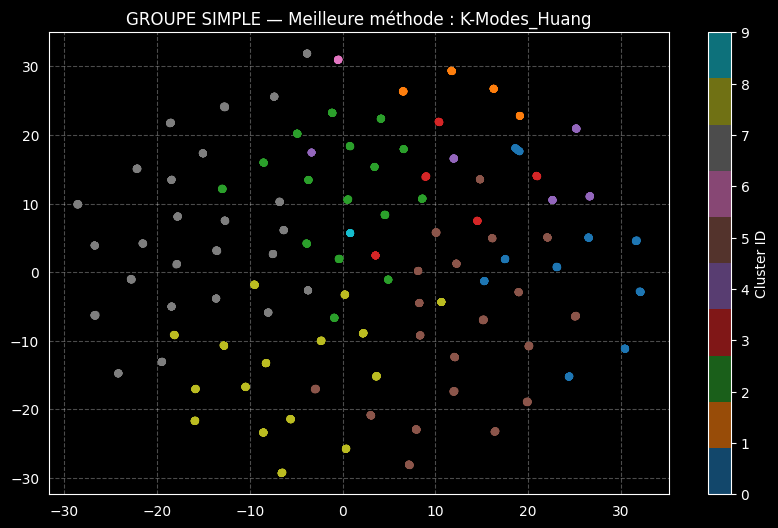


══════════════════════════════════════════════════
GROUPE : RADIO
══════════════════════════════════════════════════


KeyError: "['has_echography', 'has_scanner', 'has_radio_conventional'] not in index"

In [4]:
# Lancement

results, ranking = full_automated_pipeline(df_imputed, groups, sample_size=5000, n_jobs=128)

In [ ]:
def profile_best_clusters(df_original, cluster_labels, group_name, method_name, groups_dict):
    import pandas as pd
    import numpy as np

    df_prof = df_original.copy()
    df_prof['cluster'] = cluster_labels

    # Define pairs of (Status, Confirmation Column)
    status_pairs = {
        'bp_status': 'is_bp_measured',
        'hr_status': 'is_hr_measured',
        'temp_status': 'is_temp_measured',
        'sat_status': 'is_sat_measured',
        'rr_status': 'is_rr_measured',
        'gcs_status': 'is_gcs_measured',
        'pain_status': 'is_pain_measured',
        'cap_blood_sugar_status': 'is_cap_blood_sugar_mmol_L_measured',
        'breathalyzer_status': 'is_breathalyzer_measured',
        'o2_flow_status': 'is_o2_measured',
        'anisocoria_status': 'is_pupil_right_measured',
        'pupils_status': 'is_pupil_right_measured',
        'urine_dipstick_clean_status': 'is_urine_dipstick_clean_measured'
    }

    clinical_base_vars = ['sex', 'age_groups', 'transport_grouped', 'triage']
    clustering_vars = groups_dict[group_name]

    print(f"\n" + "═"*80)
    print(f"🔬 CLINICAL PROFILING: {group_name.upper()} (Conditional Status Analysis)")
    print(f"🏆 Method: {method_name} | N = {len(df_prof)}")
    print("═"*80)

    unique_clusters = sorted([c for c in df_prof['cluster'].unique() if c != -1])

    for cluster_id in unique_clusters:
        sub = df_prof[df_prof['cluster'] == cluster_id]
        n_sub = len(sub)
        print(f"\n📦 CLUSTER {cluster_id} | Size: {n_sub} ({n_sub/len(df_prof):.1%})")
        print("-" * 60)

        # 1. General Demographics
        for var in [v for v in clinical_base_vars if v in sub.columns]:
            top_val = sub[var].value_counts(normalize=True).idxmax()
            top_pct = sub[var].value_counts(normalize=True).max()
            print(f"   • {var.ljust(25)}: {str(top_val).ljust(15)} ({top_pct:.1%})")

        # 2. Completion Rates (Is it measured?)
        print("\n   📥 COMPLETION RATES (Activity):")
        for status_col, check_col in status_pairs.items():
            if check_col in sub.columns:
                completion = (sub[check_col].astype(float) == 1.0).mean()
                print(f"     - {check_col.ljust(33)}: Performed       ({completion:.1%})")

        # 3. Conditional Status (ONLY if measured)
        print("\n   🩺 CLINICAL STATUS (Only for patients measured):")
        for status_col, check_col in status_pairs.items():
            if status_col in sub.columns and check_col in sub.columns:
                # Filter sub-group: only those measured
                measured_only = sub[sub[check_col].astype(float) == 1.0]

                if not measured_only.empty:
                    counts = measured_only[status_col].value_counts(normalize=True)
                    top_status = counts.idxmax()
                    top_status_pct = counts.max()
                    print(f"     - {status_col.ljust(33)}: {str(top_status).ljust(15)} ({top_status_pct:.1%} of measured)")
                else:
                    print(f"     - {status_col.ljust(33)}: No data       (0 measured)")

        # 4. Clustering Signature (Care Consumption)
        print("\n   ⭐ CARE CONSUMPTION SIGNATURE:")
        for c_var in [v for v in clustering_vars if v in sub.columns]:
            rate = (sub[c_var].astype(float) == 1.0).mean()
            print(f"     * {c_var.ljust(33)}: Positive        ({rate:.1%})")

        print("\n" + "┈"*60)

    if -1 in df_prof['cluster'].values:
        print(f"⚠️ NOISE: {len(df_prof[df_prof['cluster'] == -1])} patients unclassified.")

In [ ]:
# ==========================================
# EXÉCUTION
# ==========================================

# 1. Récupération de l'index via notre nouveau nom harmonisé 'Reduction_Base'
# On prend n'importe quel groupe (ici 'simple') pour avoir l'index du sample
sample_idx = results['simple']['reductions']['Reduction_Base'].index
df_sample = df_imputed.loc[sample_idx]

# 2. Identification du groupe et de la méthode championne
group_to_test = 'radio_bio_dispo'
# On récupère la ligne du ranking qui a la meilleure Silhouette pour ce groupe
best_entry = ranking[ranking['Groupe'] == group_to_test].sort_values('Silhouette', ascending=False).iloc[0]
best_method = best_entry['Méthode']

# 3. Lancement du profilage
profile_best_clusters(
    df_sample,
    results[group_to_test]['clusters'][best_method],
    group_to_test,
    best_method,
    groups # Ton dictionnaire de groupes global
)

attention a 02 parce aue ca veut pas dire grand chose, car presaue 100% des mesurée onty de  02 en 'on', mais sinon en vrai c'est pas mal comme decoupage

TENTATIVE 1 AVEC TOUT AU PIF


In [ ]:
# # ===========================
# # Distances binaires
# # ===========================
#
# from sklearn.metrics import pairwise_distances
#
#
# def compute_distances(X, n_jobs=128):
#     # convertir en numpy booléen (indispensable pour jaccard/dice)
#     X_bool = X.to_numpy(dtype=bool)
#
#     return {
#         #"jaccard": pairwise_distances(X_bool, metric="jaccard", n_jobs=n_jobs),
#         "hamming": pairwise_distances(X_bool, metric="hamming", n_jobs=n_jobs),
#         #"dice": pairwise_distances(X_bool, metric="dice", n_jobs=n_jobs),
#         # "gower": compute_gower(X)  # garde X en DataFrame pour gower (et surtout voir si ca vaut le coup de comparer avec gower)
#     }
#
# # dice et jaccard plantent car il y a des lignes qui ont aue des zeros, et du coup la distance est indéfinie (division par zéro). Hamming lui ne pose aucun problème car il considère les 0 comme informatifs, donc il peut calculer une distance même si deux individus n’ont que des 0 en commun.

In [ ]:
# # ===========================
# # Reduction de dimension adaptée au binaire
# # ===========================
#
#
# import prince
# from sklearn.decomposition import TruncatedSVD
# from sklearn.manifold import TSNE
# import umap
#
# def reduce_dimensions(X):
#     reductions = {}
#
#     # MCA
#     mca = prince.MCA(n_components=2)
#     reductions["MCA"] = mca.fit_transform(X)
#
#     # SVD
#     svd = TruncatedSVD(n_components=2)
#     reductions["SVD"] = svd.fit_transform(X)
#
#     # UMAP
#     reducer = umap.UMAP(metric="jaccard")
#     reductions["UMAP"] = reducer.fit_transform(X)
#
#     # t-SNE
#     tsne = TSNE(n_components=2, metric="jaccard")
#     reductions["tSNE"] = tsne.fit_transform(X)
#
#     return reductions


3. Methodes de clustering adaptées au binaire

In [ ]:


# from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
# from kmodes.kmodes import KModes
# import hdbscan
#
# def run_kmodes(X, n_clusters=3):
#     km = KModes(n_clusters=n_clusters, init='Huang', n_init=5)
#     return km.fit_predict(X)
#
# def run_hierarchical(dist, n_clusters=3):
#     return AgglomerativeClustering(
#         n_clusters=n_clusters,
#         metric="precomputed",
#         linkage="average"
#     ).fit_predict(dist)

# def run_dbscan(dist, eps=0.4, min_samples=5):    apparemment ne supporte pas les lignes ou ya que des zero, surtout histoire avec eps
#     return DBSCAN(
#         eps=eps,
#         min_samples=min_samples,
#         metric="precomputed"
#     ).fit_predict(dist)



# def run_hdbscan_precomputed(dist_matrix, min_cluster_size=5):
#     # Sécurisation : remplacer les NaN (Jaccard/Dice en produisent)
#     dist_matrix = np.nan_to_num(dist_matrix, nan=0.0)
#
#     clusterer = hdbscan.HDBSCAN(
#         metric="precomputed",
#         min_cluster_size=min_cluster_size,
#         cluster_selection_epsilon=0.0
#     )
#     return clusterer.fit_predict(dist_matrix)
#
#
# def run_spectral(dist, n_clusters=3):
#     return SpectralClustering(
#         n_clusters=n_clusters,
#         affinity="precomputed"
#     ).fit_predict(1 - dist)



In [ ]:
# def cluster_all_combinations(X, distances):
#     results = {}
#
#     for dist_name, dist_matrix in distances.items():
#
#         results[dist_name] = {}
#
#         # K-modes ne dépend pas de la distance
#         results[dist_name]["k_modes"] = run_kmodes(X)
#
#         # Méthodes basées sur matrices de distances
#         results[dist_name]["hierarchical"] = run_hierarchical(dist_matrix)
#         results[dist_name]["dbscan"] = run_dbscan(dist_matrix)
#         results[dist_name]["hdbscan"] = run_hdbscan_precomputed(dist_matrix)
#         results[dist_name]["spectral"] = run_spectral(dist_matrix)
#
#     return results


In [ ]:

# import matplotlib.pyplot as plt
#
# def plot_all_combinations(reductions, clusterings, group_name):
#     for red_name, coords in reductions.items():
#         for dist_name, methods in clusterings.items():
#             for method_name, labels in methods.items():
#
#                 coords_arr = coords if isinstance(coords, np.ndarray) else coords.to_numpy()
#
#                 plt.figure(figsize=(6,5))
#                 plt.scatter(coords_arr[:,0], coords_arr[:,1], c=labels, cmap="tab10")
#                 plt.title(f"{group_name} – {red_name} – {dist_name} – {method_name}")
#                 plt.show()


4. Evaluation des clusters

In [ ]:
# from sklearn.metrics import silhouette_score, davies_bouldin_score
# import numpy as np
#
# from sklearn.metrics import silhouette_score, davies_bouldin_score
# import numpy as np
#
# def evaluate_all(X, distances, clusterings):
#     scores = {}
#
#     for dist_name, methods in clusterings.items():
#         scores[dist_name] = {}
#
#         for method_name, labels in methods.items():
#
#             labels = np.array(labels)
#
#             # 1) Vérifier qu'il y a au moins 2 clusters réels (hors bruit)
#             unique_clusters = set(labels)
#             unique_clusters_no_noise = {c for c in unique_clusters if c != -1}
#
#             if len(unique_clusters_no_noise) < 2:
#                 scores[dist_name][method_name] = {
#                     "silhouette": np.nan,
#                     "davies_bouldin": np.nan
#                 }
#                 continue
#
#             # 2) Calcul silhouette selon la distance
#             try:
#                 if dist_name in ["jaccard", "dice", "hamming"]:
#                     sil = silhouette_score(distances[dist_name], labels, metric="precomputed")
#                 else:
#                     sil = silhouette_score(X, labels)
#             except:
#                 sil = np.nan
#
#             # 3) Davies-Bouldin ne supporte pas les distances pré-calculées
#             try:
#                 db = davies_bouldin_score(X, labels)
#             except:
#                 db = np.nan
#
#             scores[dist_name][method_name] = {
#                 "silhouette": sil,
#                 "davies_bouldin": db
#             }
#
#     return scores
#


ok et explique moi comment il trouve la meilleure combinaison stp
Il identifie la meilleure combinaison en parcourant toutes les distances, toutes les méthodes, et en comparant leurs scores de silhouette pour garder celle qui maximise ce score. La logique est simple mais très systématique, et elle repose sur la structure imbriquée que tu as construite.

🔍 Comment la fonction explore les résultats
La structure scores ressemble à ceci :

python
scores = {
    "jaccard": {
        "k_modes": {"silhouette": 0.12, "davies_bouldin": 1.8},
        "hierarchical": {"silhouette": 0.25, "davies_bouldin": 1.4},
        ...
    },
    "hamming": {
        "k_modes": {"silhouette": 0.05, ...},
        "spectral": {"silhouette": 0.18, ...},
        ...
    },
    ...
}
Tu as donc 2 niveaux de clés :

niveau 1 : la distance (jaccard, hamming, dice, gower)

niveau 2 : la méthode (k_modes, hierarchical, dbscan, spectral)

La fonction find_best_combination fait exactement ceci :

1. Initialiser un "meilleur score" très bas
python
best = {"dist": None, "method": None, "silhouette": -1}
On part de -1 car un score silhouette est toujours ≥ -1, donc toute vraie valeur sera meilleure.

2. Parcourir toutes les distances
python
for dist_name, methods in scores.items():
Ici, dist_name = "jaccard", "hamming", etc.

3. Parcourir toutes les méthodes pour cette distance
python
for method_name, metrics in methods.items():
Ici, method_name = "k_modes", "hierarchical", etc.

4. Récupérer le score silhouette
python
sil = metrics["silhouette"]
5. Vérifier que le score est valide
python
if sil is not None and not np.isnan(sil)
On élimine les cas où :

DBSCAN a tout mis en cluster -1 → silhouette impossible

une méthode a échoué → NaN

6. Comparer au meilleur score actuel
python
if sil > best["silhouette"]:
    best = {
        "dist": dist_name,
        "method": method_name,
        "silhouette": sil
    }
Si le score est meilleur que celui enregistré, on met à jour :

la distance gagnante

la méthode gagnante

le score gagnant

🧠 Résultat : la meilleure combinaison
À la fin, best contient :

la distance qui donne les clusters les plus cohérents

la méthode de clustering la plus performante

le score silhouette associé

Exemple :

python
{'dist': 'jaccard', 'method': 'hierarchical', 'silhouette': 0.27}
🧩 Pourquoi c’est la bonne façon de faire ?
Parce que :

tu explores toutes les combinaisons possibles

tu compares un critère objectif (silhouette)

tu ignores les combinaisons invalides (NaN)

tu gardes la meilleure selon un critère standard de clustering

C’est exactement ce qu’on fait dans une recherche de modèle optimal.

Si tu veux, je peux aussi t’aider à :

ajouter un classement complet (tableau trié)

visualiser les scores sous forme de heatmap

choisir automatiquement le nombre optimal de clusters pour chaque méthode

donc si je cmprend bien il evalue jsute avec le score de silhouette et pas boudin ?
Oui, tu as bien compris : la fonction find_best_combination choisit la meilleure combinaison uniquement selon le score de silhouette, et pas selon le score de Davies–Bouldin.

Mais ce n’est pas une erreur : c’est un choix méthodologique. Pour que ce soit clair, voilà comment les deux scores fonctionnent et pourquoi on en utilise un plutôt que l’autre pour sélectionner le “meilleur” clustering.

🎯 Comment la sélection fonctionne exactement
La fonction find_best_combination fait ceci :

elle parcourt toutes les distances (jaccard, hamming, dice, gower)

elle parcourt toutes les méthodes (k-modes, hierarchical, dbscan, spectral)

elle récupère uniquement metrics["silhouette"]

elle garde la combinaison qui maximise ce score

Donc oui :
👉 la sélection finale se fait uniquement sur le score silhouette.

🧠 Pourquoi silhouette et pas Davies–Bouldin ?
✔️ Le score silhouette est :
plus stable,

plus interprétable,

plus comparable entre méthodes,

défini même avec des distances pré‑calculées (metric="precomputed"),

compris entre -1 et 1 (donc facile à optimiser).

C’est pour ça qu’on l’utilise comme critère principal.

✔️ Le score Davies–Bouldin est :
inversé (plus petit = meilleur),

plus sensible au nombre de clusters,

moins robuste quand les clusters sont petits ou déséquilibrés,

parfois incohérent avec des distances non euclidiennes.

Il est utile comme score secondaire, mais pas idéal comme critère de sélection.

📌 Pourquoi ta fonction evaluate_all calcule quand même les deux ?
Parce que c’est utile pour analyser la cohérence des clusters :

silhouette → cohésion + séparation

Davies–Bouldin → compacité + dispersion

Mais pour choisir un “gagnant”, silhouette est plus fiable.

🧩 Si tu veux sélectionner selon les deux scores ?
On peut créer un score combiné, par exemple :

maximiser silhouette

minimiser Davies–Bouldin

ou normaliser les deux et faire une moyenne pondérée

Exemple :

python
combined = silhouette - 0.1 * davies_bouldin
Ou encore un classement multi-critères.

🔍 Tu veux que je t’écrive une version de find_best_combination qui utilise les deux scores ?
ben jqi;erqi qu ;oins sqvoir si ca serqit les memes techniques qui serqient choisi qvec dqvies bouldin, juste en info, comment je pourrqis fqire cq ?
Tu peux tout à fait vérifier si Davies–Bouldin choisirait les mêmes techniques que Silhouette, et c’est même une très bonne idée pour comprendre la stabilité de ton pipeline. Les deux scores mesurent des choses différentes, donc il est normal qu’ils ne donnent pas toujours le même “gagnant”.

Pour répondre à ta question, il faut distinguer trois points :

comment fonctionne Davies–Bouldin,

pourquoi il peut donner un classement différent,

comment coder la comparaison.

🧠 1. Ce que mesure Davies–Bouldin (DB)
Le score DB mesure la compacité des clusters et leur séparation.
Contrairement à Silhouette :

plus petit = meilleur

il est très sensible aux clusters de tailles différentes

il favorise souvent des clusters “ronds” et compacts

il peut être instable avec des distances non euclidiennes

Donc oui, DB peut choisir une autre combinaison que Silhouette.

🔍 2. Pourquoi les deux scores peuvent diverger
Les divergences viennent de :

la nature de la distance (Jaccard vs Hamming vs Dice)

la forme des clusters (DB aime les clusters compacts)

la présence de bruit (DBSCAN peut être pénalisé)

la distribution des variables binaires (clusters très déséquilibrés)

Donc il est normal que DB et Silhouette ne donnent pas le même “meilleur” clustering.

🛠️ 3. Comment vérifier si DB choisit les mêmes techniques ?
Tu peux écrire une fonction parallèle à find_best_combination, mais basée sur DB.

✔️ Version DB seule
python
def find_best_combination_db(scores):
    best = {"dist": None, "method": None, "db": np.inf}

    for dist_name, methods in scores.items():
        for method_name, metrics in methods.items():
            db = metrics["davies_bouldin"]
            if db is not None and not np.isnan(db) and db < best["db"]:
                best = {
                    "dist": dist_name,
                    "method": method_name,
                    "db": db
                }
    return best
🧪 4. Comment comparer les deux résultats ?
Dans ton pipeline :

python
best_sil = find_best_combination(scores)
best_db = find_best_combination_db(scores)

print("→ Meilleure combinaison (Silhouette) :", best_sil)
print("→ Meilleure combinaison (Davies–Bouldin) :", best_db)
Tu verras immédiatement si :

les distances choisies sont les mêmes,

les méthodes choisies sont les mêmes,

les scores convergent ou divergent.

📊 5. Version intégrée dans full_pipeline
Tu peux ajouter ceci dans la boucle :

python
best_sil = find_best_combination(scores)
best_db = find_best_combination_db(scores)

print("→ Silhouette :", best_sil)
print("→ Davies–Bouldin :", best_db)
Et stocker les deux :

python
all_results[group_name] = {
    "distances": distances,
    "reductions": reductions,
    "clusterings": clusterings,
    "scores": scores,
    "best_silhouette": best_sil,
    "best_db": best_db
}
🎯 6. Ce que tu vas apprendre en comparant les deux
En général :

Silhouette favorise des clusters bien séparés, même s’ils sont un peu irréguliers.

Davies–Bouldin favorise des clusters compacts, même s’ils sont proches.

Donc :

si les deux scores choisissent la même combinaison → clustering robuste

s’ils divergent → structure plus complexe, clusters moins nets, ou distance mal adaptée

In [ ]:
# def find_best_combination_sil(scores):
#     best = {"dist": None, "method": None, "silhouette": -1} #On part de -1 car un score silhouette est toujours ≥ -1, donc toute vraie valeur sera meilleure
#
#     for dist_name, methods in scores.items():
#         for method_name, metrics in methods.items():
#             sil = metrics["silhouette"]
#             if sil is not None and not np.isnan(sil) and sil > best["silhouette"]:
#                 best = {
#                     "dist": dist_name,
#                     "method": method_name,
#                     "silhouette": sil
#                 }
#     return best
#
#
#
# def find_best_combination_db(scores):
#     best = {"dist": None, "method": None, "db": np.inf}
#
#     for dist_name, methods in scores.items():
#         for method_name, metrics in methods.items():
#             db = metrics["davies_bouldin"]
#             if db is not None and not np.isnan(db) and db < best["db"]:
#                 best = {
#                     "dist": dist_name,
#                     "method": method_name,
#                     "db": db
#                 }
#     return best
#
#
# def ranking_table(scores):
#     rows = []
#     for dist_name, methods in scores.items():
#         for method_name, metrics in methods.items():
#             rows.append({
#                 "distance": dist_name,
#                 "method": method_name,
#                 "silhouette": metrics["silhouette"],
#                 "davies_bouldin": metrics["davies_bouldin"]
#             })
#
#     df_rank = pd.DataFrame(rows)
#     return df_rank.sort_values(by="silhouette", ascending=False)
#


5. Visualisation des clusters

6. Pipeline global pour tous les groupes de variables

In [ ]:
# def full_pipeline(df, groups,
#                   sample_size=5000, random_state=42): # a comment pour full dataset
#     all_results = {}
#
#
#     # échantillonnage pour rendre le problème tractable   (a mettre en comment pour full data)
#     if sample_size is not None and len(df) > sample_size:
#         df = df.sample(sample_size, random_state=random_state)
#
#     print(f"Working on {len(df)} observations")
#
#     for group_name, cols in groups.items():
#         print(f"\n=== Groupe : {group_name} ===")
#
#         X = df[cols].astype(int)
#         print("NaN dans X :", X.isna().sum().sum())
#
#
#
#
#         distances = compute_distances(X)
#         reductions = reduce_dimensions(X)
#         clusterings = cluster_all_combinations(X, distances)
#         scores = evaluate_all(X, distances, clusterings)
#
#         # Trouver les meilleures combinaisons
#         best_sil = find_best_combination_sil(scores)
#         best_db = find_best_combination_db(scores)
#
#         print("→ Meilleure combinaison (Silhouette) :", best_sil)
#         print("→ Meilleure combinaison (Davies–Bouldin) :", best_db)
#
#         # Tableau comparatif
#         df_rank = ranking_table(scores)
#         print("\nClassement complet :")
#         display(df_rank)
#
#         plot_all_combinations(reductions, clusterings, group_name)
#
#         all_results[group_name] = {
#             "distances": distances,
#             "reductions": reductions,
#             "clusterings": clusterings,
#             "scores": scores,
#             "best_silhouette": best_sil,
#             "best_db": best_db,
#             "ranking": df_rank
#         }
#
#     return all_results
#
#


In [ ]:
# results = full_pipeline(df_imputed, groups)
